# Phase 5 — Exploratory data analysis

**Input:** `data/clean.parquet` · **Output:** 12 charts in `reports/figures/`, each followed by its insight.

Reminder: Severity = **impact on traffic (delay)**, not injuries. "High impact" below means Severity 3–4.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

FIGS = Path("../reports/figures")
FIGS.mkdir(parents=True, exist_ok=True)
SEV_COLORS = ["#9ecae1", "#4292c6", "#fd8d3c", "#a50f15"]  # Severity 1..4, light -> dark red
sns.set_theme(style="whitegrid", font_scale=0.95)

df = pd.read_parquet("../data/clean.parquet")
t = df["Start_Time"]  # local time of the accident
df = df.assign(hour=t.dt.hour, weekday=t.dt.dayofweek, month=t.dt.month, year=t.dt.year,
               high_impact=df["Severity"].ge(3))
print(df.shape)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / f"{name}.png", dpi=120, bbox_inches="tight")


def severity_share(by):
    """% of each Severity inside each group of `by` (rows sum to 100)."""
    return pd.crosstab(by, df["Severity"], normalize="index").mul(100)


def stacked(share, ax, horizontal=False):
    share.plot(kind="barh" if horizontal else "bar", stacked=True, color=SEV_COLORS, width=0.85, ax=ax)
    (ax.xaxis if horizontal else ax.yaxis).set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Severity", bbox_to_anchor=(1.01, 1), loc="upper left")

(495532, 41)


## 0. Descriptive statistics

Numeric weather variables (after cleaning). `skew` > 0 = long right tail, < 0 = long left tail.

In [2]:
from scipy import stats
import numpy as np

NUMERIC = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
desc = df[NUMERIC].describe().T
desc["missing_%"] = df[NUMERIC].isna().mean() * 100
desc["skew"] = df[NUMERIC].skew()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_%,skew
Temperature(F),485403.0,61.64,18.99,-35.00,49.00,64.00,76.00,117.00,2.04,-0.51
Humidity(%),484751.0,64.84,22.83,1.00,48.00,67.00,84.00,100.00,2.18,-0.40
Pressure(in),486935.0,29.54,1.01,19.36,29.37,29.86,30.03,31.15,1.73,-3.68
Visibility(mi),484590.0,9.09,2.69,0.00,10.00,10.00,10.00,100.00,2.21,2.32
Wind_Speed(mph),458913.0,7.68,5.27,0.00,4.60,7.00,10.40,142.00,7.39,0.93
Precipitation(in),495532.0,0.01,0.09,0.00,0.00,0.00,0.00,10.13,0.00,91.80


In [3]:
# Categorical variables: number of values and most common value
CATEG = ["Source", "State", "Weather_Group", "Wind_Direction", "Sunrise_Sunset"]
pd.DataFrame({c: {"n_values": df[c].nunique(), "most_common": df[c].value_counts().index[0],
                  "most_common_%": round(df[c].value_counts(normalize=True).iloc[0] * 100, 1)} for c in CATEG}).T

,n_values,most_common,most_common_%
Source,3,Source1,55.6
State,49,CA,22.7
Weather_Group,9,Clear,43.7
Wind_Direction,19,CALM,17.3
Sunrise_Sunset,2,Day,69.2


In [4]:
# Median of each numeric variable per Severity level
df.groupby("Severity")[NUMERIC].median()

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
Severity,,,,,,
1,73.0,68.0,29.55,10.0,7.0,0.0
2,64.0,67.0,29.84,10.0,7.0,0.0
3,64.9,67.0,29.93,10.0,8.0,0.0
4,60.0,70.0,29.81,10.0,7.0,0.0


**Reading:** most weather values are typical (median 64 °F, 10 miles visibility, no rain). Precipitation (skew 92)
and visibility (2.3) are very skewed: most accidents happen in dry, clear weather, with a few extreme values.
Pressure is skewed to the left (stations at high altitude). So medians describe these variables better than means,
and the median is also used to fill missing values. The medians barely change between severity levels, except
temperature (Severity 4 is colder: 60 °F vs 64 °F).

## 1. How imbalanced is Severity?

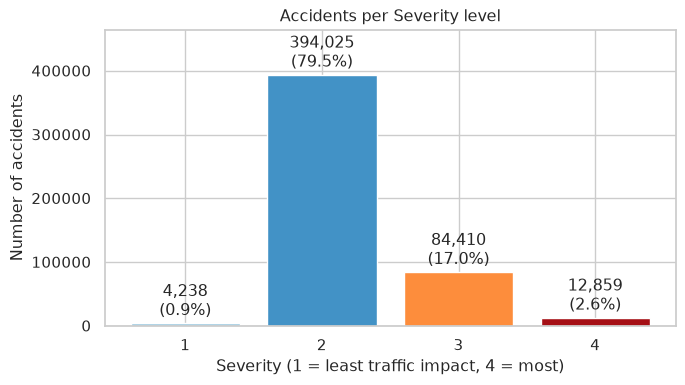

In [5]:
counts = df["Severity"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index.astype(str), counts, color=SEV_COLORS)
ax.bar_label(bars, labels=[f"{n:,}\n({n / len(df):.1%})" for n in counts], padding=2)
ax.set(title="Accidents per Severity level", xlabel="Severity (1 = least traffic impact, 4 = most)",
       ylabel="Number of accidents", ylim=(0, counts.max() * 1.18))
save(fig, "01_severity_distribution")

**Insight:** 80% of accidents are Severity 2, while Severity 1 (0.9%) and Severity 4 (2.6%) are rare.
Always predicting "2" would already be 80% accurate, which is why accuracy is useless here and the main metric is **macro F1**.

## 2. When do accidents happen?

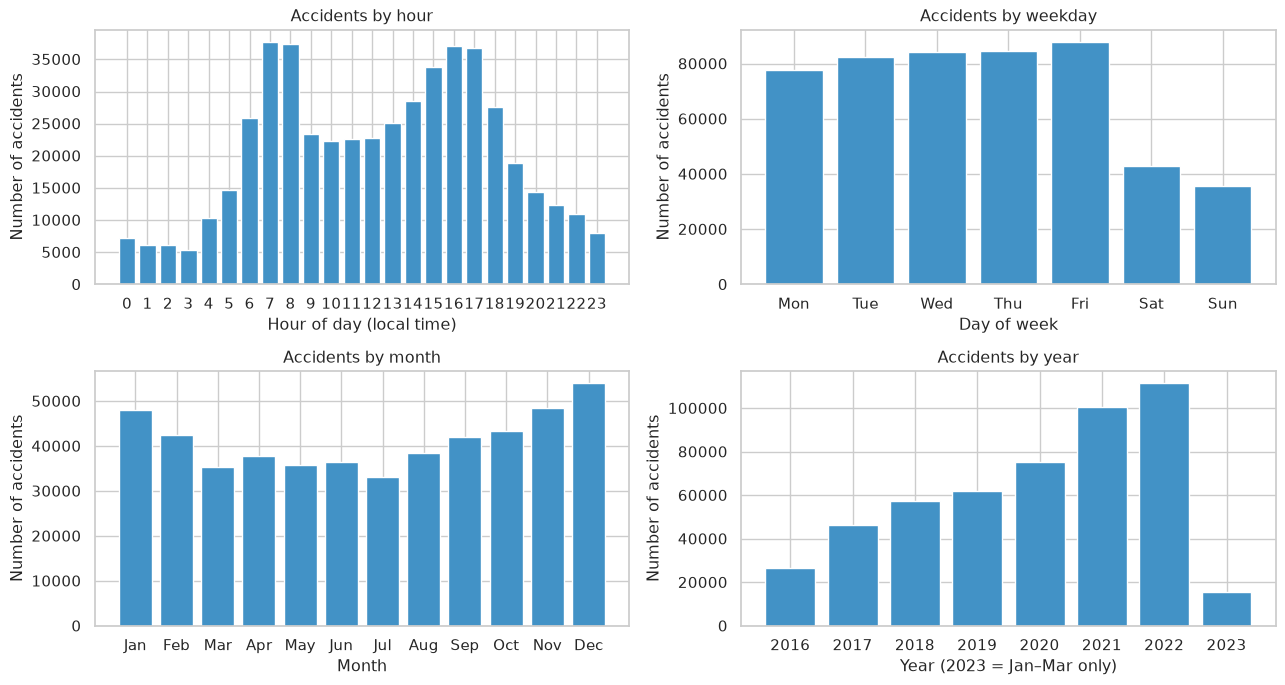

In [6]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, col, xlabel, ticks in [(axes[0, 0], "hour", "Hour of day (local time)", None),
                               (axes[0, 1], "weekday", "Day of week", DAYS),
                               (axes[1, 0], "month", "Month", MONTHS),
                               (axes[1, 1], "year", "Year (2023 = Jan–Mar only)", None)]:
    s = df[col].value_counts().sort_index()
    ax.bar(ticks or s.index.astype(str), s, color="#4292c6")
    ax.set(title=f"Accidents by {col}", xlabel=xlabel, ylabel="Number of accidents")
save(fig, "02_accidents_by_time")

**Insight:** accidents peak at the morning (7–8 h) and evening (15–17 h) rush hours, are about half as frequent
on weekends as on weekdays, and are most frequent in December–January. The yearly rise mostly reflects
better data collection, not more accidents (see chart 12).

## 3. Are rush-hour or night accidents more severe?

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
severity_4_%,6.3,4.6,5.0,5.3,3.7,3.2,2.1,1.6,1.7,2.5,...,2.3,2.1,1.9,2.0,2.4,3.2,3.8,4.1,4.3,5.0


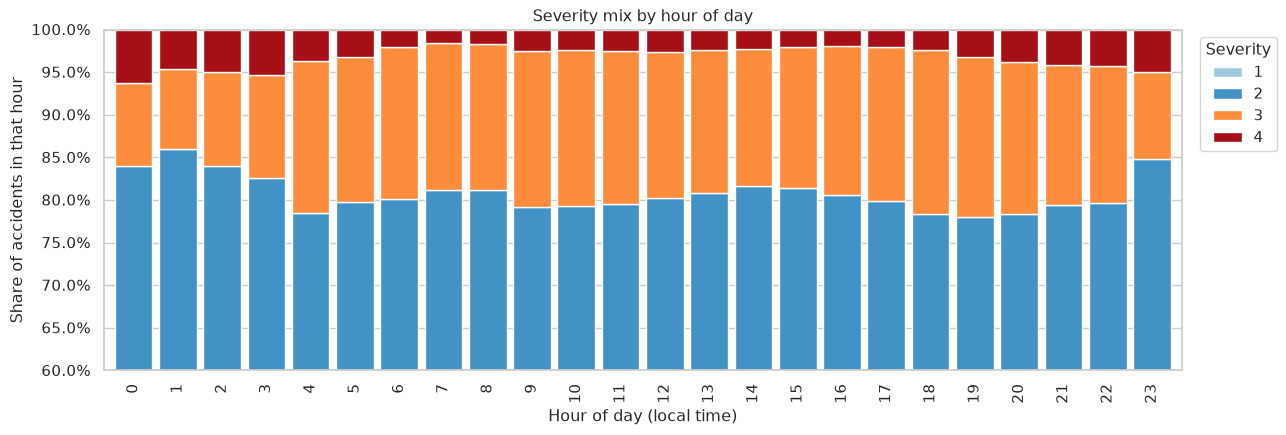

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
stacked(severity_share(df["hour"]), ax)
ax.set(title="Severity mix by hour of day", xlabel="Hour of day (local time)", ylabel="Share of accidents in that hour")
ax.set_ylim(60, 100)  # zoom: Severity 1 + most of Severity 2 sit below 60%
save(fig, "03_severity_by_hour")
severity_share(df["hour"])[4].round(1).to_frame("severity_4_%").T

**Insight:** rush hour does **not** mean higher severity: Severity 4 is lowest at 7–8 h (1.6%) and highest
around midnight (5–6%). Night accidents are rarer but more often long-delay ones (likely fewer responders and
more highway driving). Note the y-axis starts at 60%.

## 4. Where do accidents happen?

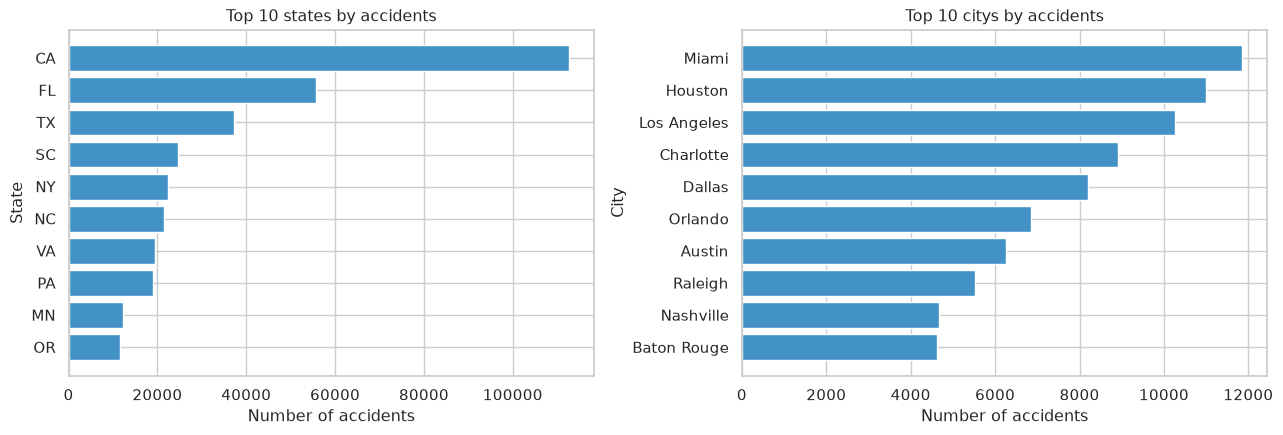

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["State", "City"]):
    top = df[col].value_counts().head(10)[::-1]
    ax.barh(top.index.astype(str), top, color="#4292c6")
    ax.set(title=f"Top 10 {col.lower()}s by accidents", xlabel="Number of accidents", ylabel=col)
save(fig, "04_top_states_cities")

**Insight:** California alone has 23% of all accidents, then Florida (11%) and Texas (7.5%). The top cities are
Miami, Houston and Los Angeles. Counts follow population **and** how well each area is covered by the data providers.

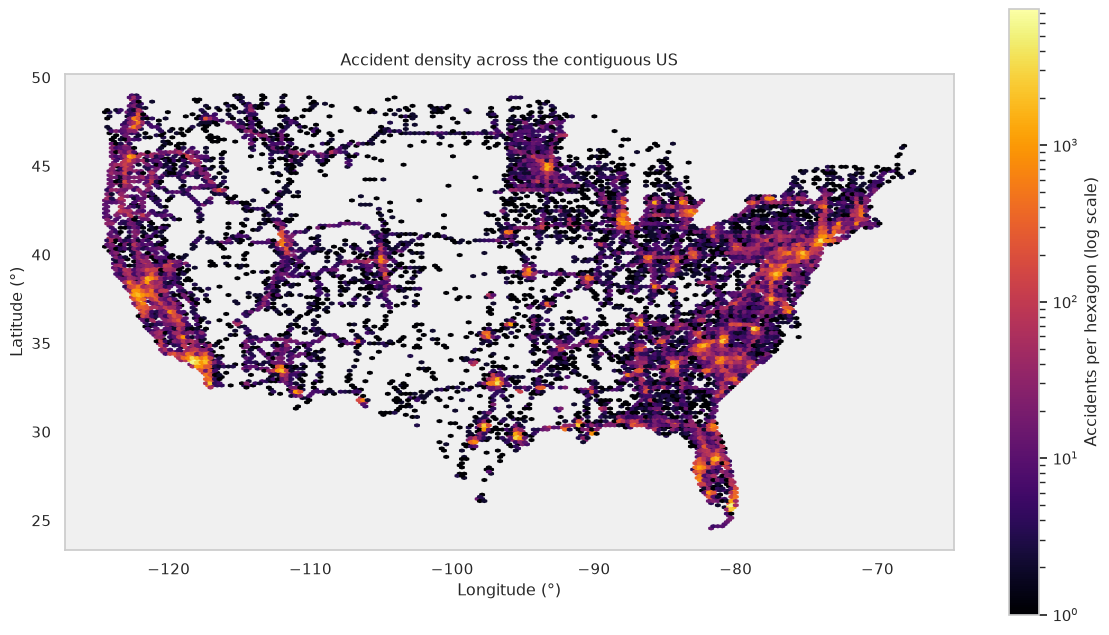

In [9]:
# All 495K points as hexagons (log colour scale); static, so it also works in the PDF report
fig, ax = plt.subplots(figsize=(12, 6.5))
hb = ax.hexbin(df["Start_Lng"], df["Start_Lat"], gridsize=180, bins="log", cmap="inferno", mincnt=1)
fig.colorbar(hb, ax=ax, label="Accidents per hexagon (log scale)")
ax.set(title="Accident density across the contiguous US", xlabel="Longitude (°)", ylabel="Latitude (°)")
ax.set_aspect(1.25)
ax.set_facecolor("#f0f0f0")
ax.grid(False)
save(fig, "05_accident_density_map")

**Insight:** accidents trace the road network and big metro areas (LA, Bay Area, Miami, Houston, the
East-Coast corridor); the empty Mountain West shows how strongly counts follow population and coverage.

## 5. Does weather matter?

,severity_3_4_%,rows
Weather_Group,,
Other,8.9,203
Windy,14.1,5155
Fog / Haze / Smoke,16.4,13084
Clear,17.3,216488
Snow / Ice,19.5,11278
Unknown,21.6,10750
Cloudy,21.8,200063
Heavy rain / Thunderstorm,22.1,7882
Rain,22.6,30629


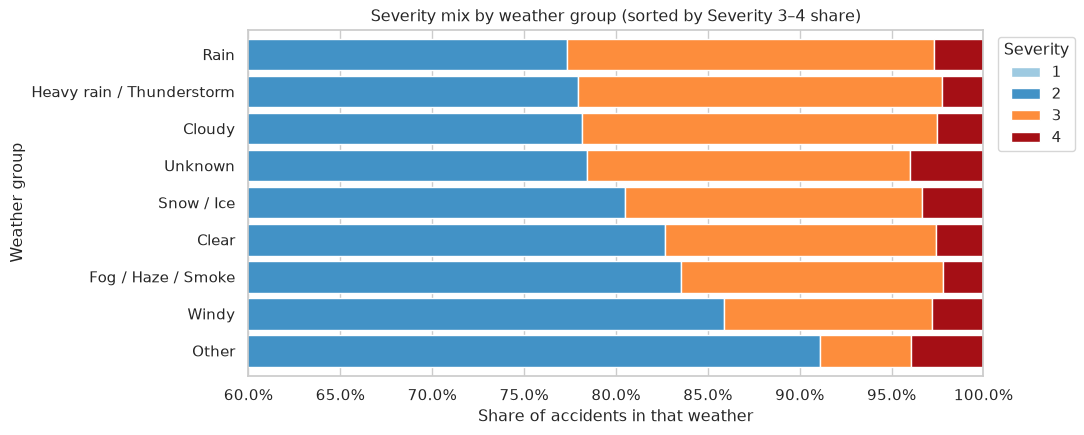

In [10]:
share = severity_share(df["Weather_Group"])
share = share.loc[share[[3, 4]].sum(axis=1).sort_values().index]  # sort by high-impact share
fig, ax = plt.subplots(figsize=(11, 4.5))
stacked(share, ax, horizontal=True)
ax.set(title="Severity mix by weather group (sorted by Severity 3–4 share)",
       xlabel="Share of accidents in that weather", ylabel="Weather group")
ax.set_xlim(60, 100)
save(fig, "06_severity_by_weather")
pd.concat([share[[3, 4]].sum(axis=1).round(1).rename("severity_3_4_%"),
           df["Weather_Group"].value_counts().rename("rows")], axis=1)

**Insight:** weather has a moderate effect. Rain, thunderstorms and cloudy skies have the highest Severity 3–4
share (~22%), against ~17% in clear weather. Snow/ice raises Severity 4 (3.4% vs 2.6% when clear).
The x-axis starts at 60%.

,Visibility(mi),Temperature(F)
Severity,,
1,10.0,73.0
2,10.0,64.0
3,10.0,64.9
4,10.0,60.0


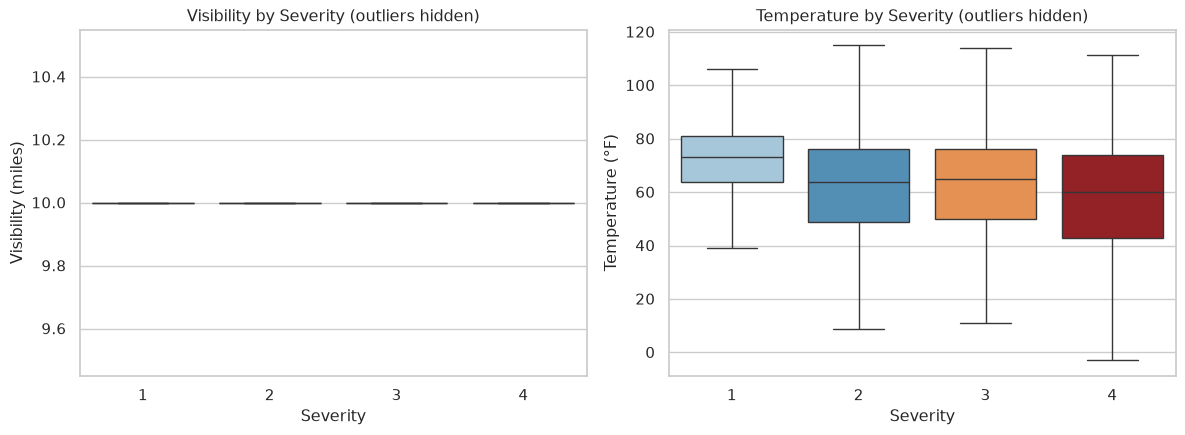

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, unit in [(axes[0], "Visibility(mi)", "miles"), (axes[1], "Temperature(F)", "°F")]:
    sns.boxplot(data=df, x="Severity", y=col, hue="Severity", palette=SEV_COLORS, legend=False,
                showfliers=False, ax=ax)
    ax.set(title=f"{col.split('(')[0]} by Severity (outliers hidden)", xlabel="Severity", ylabel=f"{col.split('(')[0]} ({unit})")
save(fig, "07_visibility_temperature_by_severity")
df.groupby("Severity")[["Visibility(mi)", "Temperature(F)"]].median()

**Insight:** visibility does not separate the classes (median 10 mi for all: most accidents happen in good
visibility). Severity 4 accidents happen in slightly colder weather (median 60 °F vs 64 °F for Severity 2),
consistent with winter conditions causing longer delays.

## 6. Do road features matter?

,feature absent,feature present
Junction,19.0,27.2
Traffic_Signal,21.4,9.6
Crossing,21.2,7.2
Stop,20.0,6.2


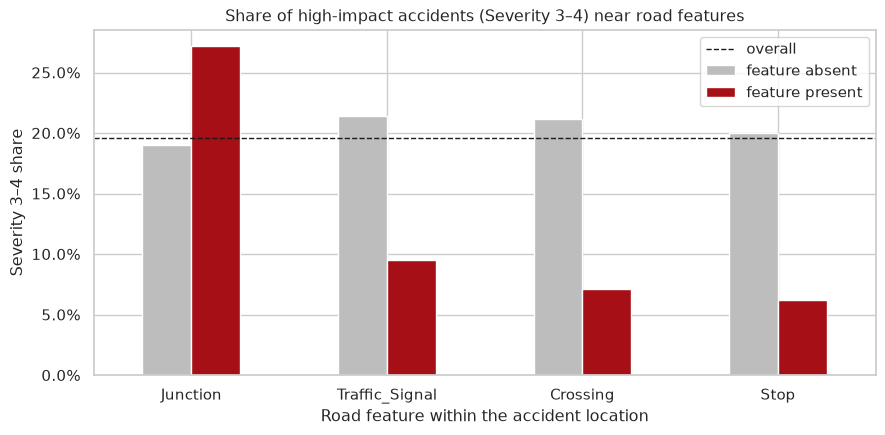

In [12]:
ROAD = ["Junction", "Traffic_Signal", "Crossing", "Stop"]
road = pd.DataFrame({f: df.groupby(f)["high_impact"].mean() * 100 for f in ROAD}).T
road.columns = ["feature absent", "feature present"]
fig, ax = plt.subplots(figsize=(9, 4.5))
road.plot.bar(ax=ax, color=["#bdbdbd", "#a50f15"], rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.axhline(df["high_impact"].mean() * 100, color="k", ls="--", lw=1, label="overall")
ax.set(title="Share of high-impact accidents (Severity 3–4) near road features",
       xlabel="Road feature within the accident location", ylabel="Severity 3–4 share")
ax.legend()
save(fig, "08_road_features")
road.round(1)

**Insight:** accidents near traffic signals, crossings and stop signs are **much less** likely to be high impact
(6–10% vs ~20%): these are slow city streets. Junctions are the exception (27%), because they include highway
on/off ramps. Road features are strong signals for the model.

## 7. Day or night?

Severity,1,2,3,4
Sunrise_Sunset,,,,
Day,1.0,79.1,17.7,2.2
Night,0.5,80.4,15.6,3.5


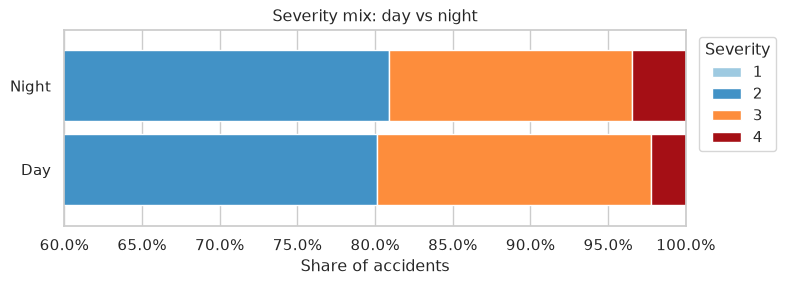

In [13]:
share = severity_share(df["Sunrise_Sunset"])
fig, ax = plt.subplots(figsize=(8, 3))
stacked(share, ax, horizontal=True)
ax.set(title="Severity mix: day vs night", xlabel="Share of accidents", ylabel="")
ax.set_xlim(60, 100)
save(fig, "09_severity_day_night")
share.round(1)

**Insight:** night accidents are Severity 4 more often than day accidents (3.5% vs 2.2%, ×1.6),
confirming chart 3. The x-axis starts at 60%.

## 8. Are numeric features related?

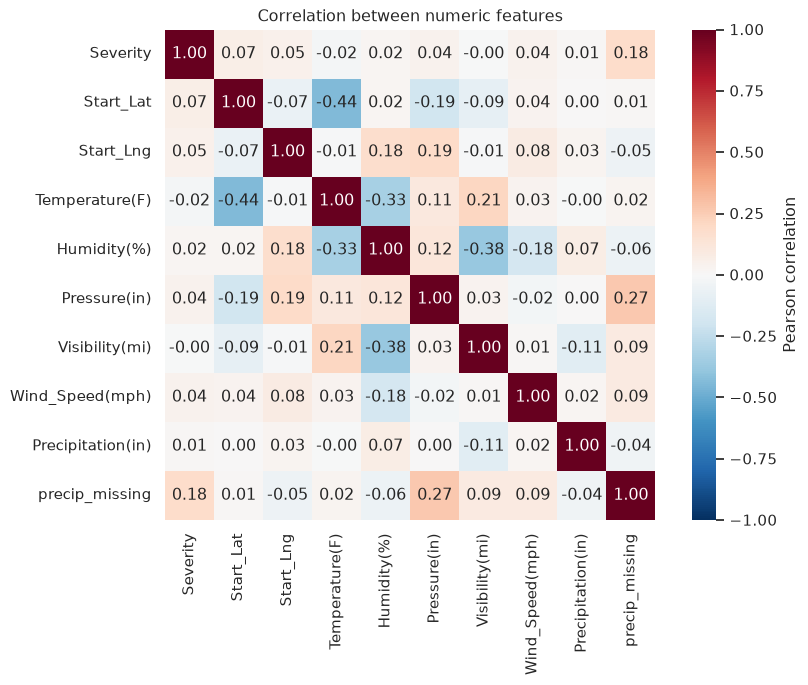

In [14]:
NUM = ["Severity", "Start_Lat", "Start_Lng", "Temperature(F)", "Humidity(%)", "Pressure(in)",
       "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "precip_missing"]
corr = df[NUM].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set(title="Correlation between numeric features")
save(fig, "10_correlation_heatmap")

**Insight:** no single numeric feature is linearly related to Severity (all |r| < 0.1), so the signal is
non-linear and comes from combinations (time + place + road) — a job for tree models rather than a linear one.
Temperature–Latitude (−0.44) and Humidity–Temperature/Visibility are the only notable pairs; no feature is
redundant enough to drop.

## 9. Is the data stable over time?

Severity,1,2,3,4
year,,,,
2016,0.1,65.9,30.7,3.3
2017,0.0,64.2,32.4,3.3
2018,0.0,64.4,32.8,2.8
2019,0.0,71.9,25.1,3.0
2020,2.4,79.1,15.9,2.6
2021,0.0,88.5,9.6,1.9
2022,2.1,90.9,4.5,2.4
2023,0.0,97.0,0.0,3.0


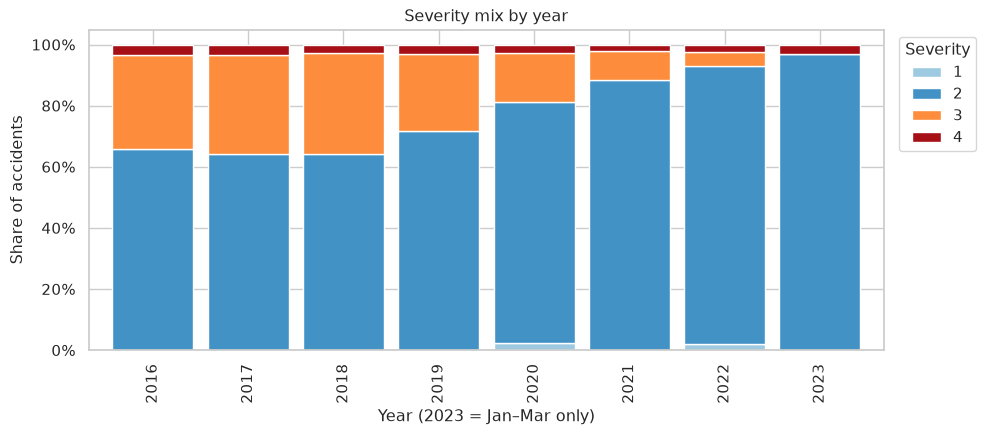

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
stacked(severity_share(df["year"]), ax)
ax.set(title="Severity mix by year", xlabel="Year (2023 = Jan–Mar only)", ylabel="Share of accidents")
save(fig, "11_severity_by_year")
severity_share(df["year"]).round(1)

Severity,1,2,3,4
Source,,,,
Source1,0.6,91.2,3.8,4.3
Source2,1.0,64.9,33.6,0.4
Source3,4.4,64.7,30.8,0.1


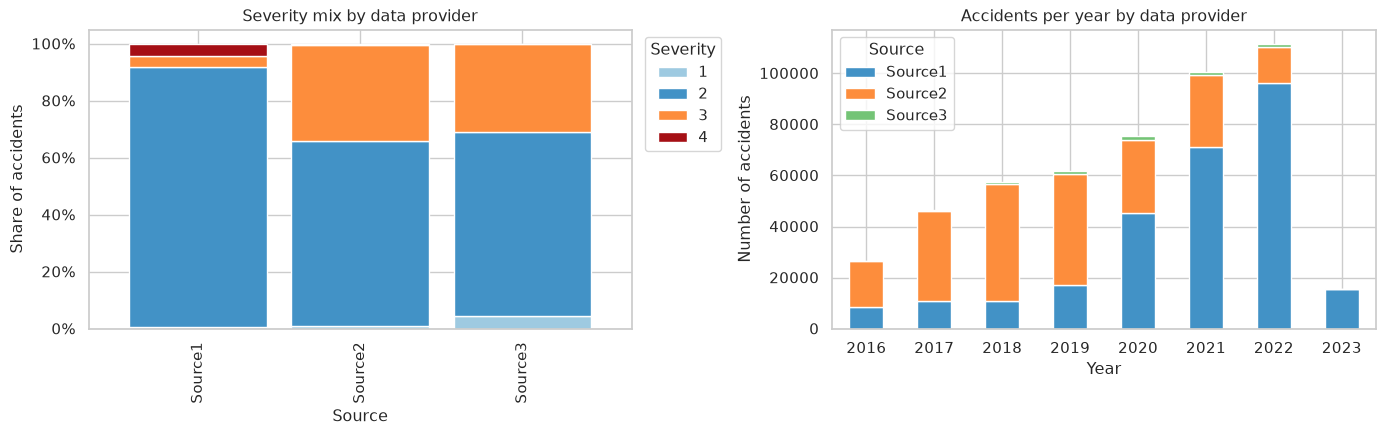

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
stacked(severity_share(df["Source"]), axes[0])
axes[0].set(title="Severity mix by data provider", xlabel="Source", ylabel="Share of accidents")
pd.crosstab(df["year"], df["Source"]).plot.bar(stacked=True, ax=axes[1], color=["#4292c6", "#fd8d3c", "#74c476"], rot=0)
axes[1].set(title="Accidents per year by data provider", xlabel="Year", ylabel="Number of accidents")
save(fig, "12_severity_by_source")
severity_share(df["Source"]).round(1)

**Insight:** the data is **not** stable. Severity 3 falls from ~32% (2016–18) to 0% (2023). The reason is the
providers: Source2 labels 34% of accidents as Severity 3, Source1 only 4% (but 4.3% as Severity 4, vs 0.4%).
Source2's share falls from 68% of rows (2016) to 0% (2023). So part of "severity" is **how a provider records it**.
This must be handled in Phase 9 (model with/without `Source`) and explains the drop expected in the time-based test (Phase 7).

## 10. Statistical hypothesis tests

The charts suggest relationships; the tests check they are not just chance. Significance level **α = 0.05**.

**Which test and why**
- Two **categorical** variables (e.g. Severity vs day/night) → **chi-square test of independence**.
  H0: the two variables are independent. Assumption: every expected count ≥ 5 (checked: `min_expected`).
- A **numeric** variable across the 4 Severity groups (temperature) → **Kruskal-Wallis test**.
  H0: the 4 groups have the same distribution. Chosen instead of ANOVA because temperature is not normally
  distributed and the group variances differ (both checked below), and Kruskal-Wallis does not need those assumptions.

**Big-sample warning:** with ~500,000 rows, even tiny differences give p ≈ 0. So each test also reports an
**effect size** (how big the difference is) and is repeated on a random **5,000-row sample**:
- Cramér's V (chi-square): 0.1 small, 0.3 medium, 0.5 large.
- ε² (Kruskal-Wallis): 0.01 small, 0.06 medium, 0.14 large.

In [17]:
def effect(v, cuts=(0.1, 0.3, 0.5)):
    return "negligible" if v < cuts[0] else "small" if v < cuts[1] else "medium" if v < cuts[2] else "large"


def chi2_test(name, a, b, sample=None):
    ct = pd.crosstab(a, b)
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.to_numpy().sum() * (min(ct.shape) - 1)))
    p5k = stats.chi2_contingency(pd.crosstab(a.loc[sample], b.loc[sample]))[1]
    return {"H0: Severity independent of": name, "chi2": round(chi2), "dof": dof, "p_value": p,
            "min_expected": round(exp.min(), 1), "cramers_v": round(v, 3), "effect": effect(v),
            "p_value_5k_sample": p5k, "reject_H0": p < 0.05}


s5k = df.sample(5_000, random_state=42).index
known = df["Weather_Group"].ne("Other")  # "Other" (203 rows) gives expected counts < 5 -> excluded
tests = pd.DataFrame([
    chi2_test("data provider (Source)", df["Source"], df["Severity"], s5k),
    chi2_test("day / night", df["Sunrise_Sunset"], df["Severity"], s5k),
    chi2_test("traffic signal nearby", df["Traffic_Signal"], df["Severity"], s5k),
    chi2_test("junction nearby", df["Junction"], df["Severity"], s5k),
    chi2_test("weather group (without 'Other')", df.loc[known, "Weather_Group"].astype(str),
              df.loc[known, "Severity"], s5k.intersection(df.index[known])),
])
pd.set_option("display.float_format", lambda x: f"{x:.3g}")
tests

,H0: Severity independent of,chi2,dof,p_value,min_expected,cramers_v,effect,p_value_5k_sample,reject_H0
0,data provider (Source),82258,6,0,54.1,0.288,small,3.79e-182,True
1,day / night,1242,3,6.98e-269,1.31e+03,0.05,negligible,0.000367,True
2,traffic signal nearby,7336,3,0,630,0.122,small,7.67e-13,True
3,junction nearby,1466,3,0,314,0.054,negligible,0.127,True
4,weather group (without 'Other'),2264,21,0,44.1,0.039,negligible,0.013,True


In [18]:
# Assumption checks for temperature (numeric across 4 groups)
temp = [df.loc[df["Severity"] == s, "Temperature(F)"].dropna() for s in (1, 2, 3, 4)]
print("Normality (D'Agostino, 5,000-row sample): p =", f"{stats.normaltest(temp[1].sample(5000, random_state=42)).pvalue:.2g}",
      "-> not normal" )
print("Equal variances (Levene): p =", f"{stats.levene(*temp).pvalue:.2g}", "-> variances differ")

H, p = stats.kruskal(*temp)
n = sum(len(g) for g in temp)
eps2 = (H - len(temp) + 1) / (n - len(temp))
t5k = df.loc[s5k]
p5k = stats.kruskal(*[t5k.loc[t5k["Severity"] == s, "Temperature(F)"].dropna() for s in (1, 2, 3, 4)]).pvalue
pd.DataFrame([{"H0": "Temperature is the same for all Severity levels", "H": round(H, 1), "p_value": p,
               "epsilon_squared": round(eps2, 4), "effect": effect(eps2, (0.01, 0.06, 0.14)),
               "p_value_5k_sample": p5k, "reject_H0": p < 0.05,
               "medians_by_severity": [round(g.median(), 1) for g in temp]}])

Normality (D'Agostino, 5,000-row sample): p = 3.7e-41 -> not normal
Equal variances (Levene): p = 1e-194 -> variances differ


,H0,H,p_value,epsilon_squared,effect,p_value_5k_sample,reject_H0,medians_by_severity
0,Temperature is the same for all Severity levels,1.82e+03,0,0.0037,negligible,2.41e-05,True,"[73.0, 64.0, 64.9, 60.0]"


**Interpretation**
- **Data provider (Source):** H0 rejected; the strongest relationship tested (V = 0.29, at the top of "small",
  just under "medium"), and still clearly significant on only 5,000 rows (p ≈ 10^-182).
  Severity depends a lot on *who reported* the accident.
- **Traffic signal nearby:** H0 rejected, **small** effect (V = 0.12), significant on 5,000 rows:
  accidents near signals are less often severe (slow city streets).
- **Day / night** and **weather group:** H0 rejected, still significant on 5,000 rows, but the effects are
  **negligible** (V = 0.05 and 0.04): real but weak signals.
- **Junction nearby:** **negligible** effect (V = 0.05) and *not* significant on 5,000 rows (p = 0.13):
  the weakest relationship.
- **Temperature (Kruskal-Wallis):** H0 rejected, even on 5,000 rows, but ε² = 0.004 is **negligible**:
  Severity 4 accidents are only a little colder (median 60 °F vs 64 °F).

**Conclusion:** with a huge sample, almost everything is "significant", so effect sizes decide what matters.
The data provider and the road context have the largest effects; light and weather conditions have small ones.
No single variable explains severity on its own, which supports using many features together in a
non-linear model.

## Key findings

1. **Strong imbalance:** 80% Severity 2, 2.6% Severity 4 → use macro F1, class weights, per-class recall.
2. **Provider bias is the biggest pattern in the data:** Source2 records far more Severity 3, Source1 far more Severity 4,
   and the provider mix changes by year → severity shifts over time. `Source` will likely be a top feature; its ablation is essential.
3. **Night > rush hour:** Severity 4 is highest around midnight (5–6%) and lowest at morning rush (1.6%).
4. **Road context matters:** signals, crossings and stops → slow city streets → 2–3× less high-impact;
   junctions (incl. ramps) → more high-impact.
5. **Weather matters moderately:** rain/storms raise Severity 3–4 share by ~5 points; snow/ice raises Severity 4.
6. **No linear signal** in numeric features → expect tree models (Random Forest, LightGBM) to beat Logistic Regression.
7. **Hypothesis tests confirm it:** all tested relationships are significant, but effect sizes rank them:
   provider (V = 0.29) > traffic signal (0.12) > day/night, junction, weather (≤ 0.05); temperature differs only slightly (ε² = 0.004).